# RNA-seq Baseline — Improved Preprocessing

Pipeline: low-expression gene filtering → log2(CPM + 1) → StandardScaler → SelectKBest → PCA → classifier

**Experiment A**: SelectKBest + PCA + LR/RF (default params)  
**Experiment B**: SelectKBest + LR with very small C (no PCA — L1 acts as built-in feature selection)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

from hcc_multimodal.baselines.config import RANDOM_STATE
from hcc_multimodal.baselines.transforms import DataType, build_preprocessor
from hcc_multimodal.baselines.evaluation import (
    plot_cv_results,
    plot_experiment_comparison,
)

In [2]:
# ── Configuration ──────────────────────────────────────────────
SELECT_K = 500
MAX_ITER = 5000
LR_C = 1.0           # default C for Experiment A
LR_C_SMALL = 0.1     # small C for Experiment B (strong L1 regularisation, no PCA)

## Load and preprocess RNA data

In [3]:
ROOT = Path().resolve().parents[1]

clinical_data = pd.read_csv(
    ROOT / "data" / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

radiomics_data = pd.read_csv(
    ROOT / "data" / "Radiomics" / "radiomic_cluster.csv"
).dropna(how="all")

rna_raw = pd.read_csv(
    ROOT / "data" / "RNA_seq" / "Matrix_output_radiology_only.csv"
).dropna(how="all")

# Transpose to (samples × genes)
gene_symbols = rna_raw["Gene Symbol"]
count_matrix = rna_raw.drop(columns=["ENSEMBL Gene ID", "Gene Symbol"]).T
count_matrix.columns = gene_symbols.values
count_matrix = count_matrix.loc[:, ~pd.isnull(count_matrix.columns)]
count_matrix = count_matrix.loc[:, ~count_matrix.columns.duplicated()]
count_matrix = count_matrix.apply(pd.to_numeric, errors="coerce")
count_matrix.index = count_matrix.index.astype(int)

print(f"Raw: {count_matrix.shape[0]} samples × {count_matrix.shape[1]} genes")
print(f"Library size range: {count_matrix.sum(axis=1).min():,.0f} – {count_matrix.sum(axis=1).max():,.0f}")

# Filter low-expression genes (count > 10 in ≥ 20% of samples)
min_samples = int(0.2 * count_matrix.shape[0])
gene_mask = (count_matrix > 10).sum(axis=0) >= min_samples
count_filtered = count_matrix.loc[:, gene_mask]
print(f"After filtering: {count_filtered.shape[1]} genes kept ({count_matrix.shape[1] - count_filtered.shape[1]} removed)")

# log2(CPM + 1)
library_sizes = count_filtered.sum(axis=1)
cpm = count_filtered.div(library_sizes, axis=0) * 1e6
rna_norm = np.log2(cpm + 1)

rna_data = rna_norm.rename_axis("SID").reset_index()
rna_cols = [c for c in rna_data.columns if c != "SID"]
print(f"Final: {len(rna_cols)} features, value range [{rna_norm.values.min():.2f}, {rna_norm.values.max():.2f}]")

Raw: 60 samples × 50986 genes
Library size range: 234,195 – 159,005,270
After filtering: 21241 genes kept (29745 removed)
Final: 21241 features, value range [0.00, 18.00]


In [4]:
# Prepare targets
radiomic_death = radiomics_data[["SID", "death"]].copy()
rna_x_columns = {col: DataType.CONTINUOUS for col in rna_cols}

# Merge datasets
rna_death = rna_data.merge(radiomic_death, on="SID", how="inner")
rna_os = rna_data.merge(clinical_data[["SID", "OS_central_event"]], on="SID", how="inner")

X_death = rna_death[rna_cols].reset_index(drop=True)
y_death = rna_death["death"].reset_index(drop=True)
X_os = rna_os[rna_cols].reset_index(drop=True)
y_os = rna_os["OS_central_event"].reset_index(drop=True)

print(f"RNA → death:             n={len(y_death.dropna())}, positives={int(y_death.dropna().sum())}")
print(f"RNA → OS_central_event:  n={len(y_os.dropna())}, positives={int(y_os.dropna().sum())}")

RNA → death:             n=60, positives=24
RNA → OS_central_event:  n=56, positives=21


In [5]:
def run_experiment(
    X, y, x_columns, label, models, select_k=None, use_pca=True, n_splits=3,
):
    """Run stratified k-fold CV with configurable pipeline."""
    preprocessor = build_preprocessor(x_columns)
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    mask = ~y.isna()
    X_clean, y_clean = X[mask], y[mask]
    print(f"[{label}]  n={len(y_clean)}  positives={int(y_clean.sum())}  features={X_clean.shape[1]}")

    records, fold_records = [], []
    for model_name, model in models.items():
        steps = [("preprocessor", preprocessor)]
        if select_k is not None:
            steps.append(("select_k", SelectKBest(f_classif, k=select_k)))
        if use_pca:
            steps.append(("pca", PCA(n_components=0.9, random_state=RANDOM_STATE)))
        steps.append(("model", model))
        pipe = Pipeline(steps)

        scores = cross_validate(
            pipe, X_clean, y_clean, cv=outer_cv,
            scoring=["roc_auc", "accuracy"], return_train_score=True,
        )
        records.append({
            "experiment": label, "model": model_name,
            "AUC mean": round(scores["test_roc_auc"].mean(), 3),
            "AUC std": round(scores["test_roc_auc"].std(), 3),
            "Accuracy mean": round(scores["test_accuracy"].mean(), 3),
            "Accuracy std": round(scores["test_accuracy"].std(), 3),
        })
        for fold_i, (train_auc, test_auc) in enumerate(
            zip(scores["train_roc_auc"], scores["test_roc_auc"])
        ):
            fold_records.append({
                "experiment": label, "model": model_name,
                "fold": fold_i + 1, "train_auc": train_auc,
                "test_auc": test_auc, "best_params": {},
            })
    return pd.DataFrame(records), pd.DataFrame(fold_records)

## Experiment A: SelectKBest + PCA + LR/RF

[RNA(log2CPM)+KBest → death]  n=60  positives=24  features=21241


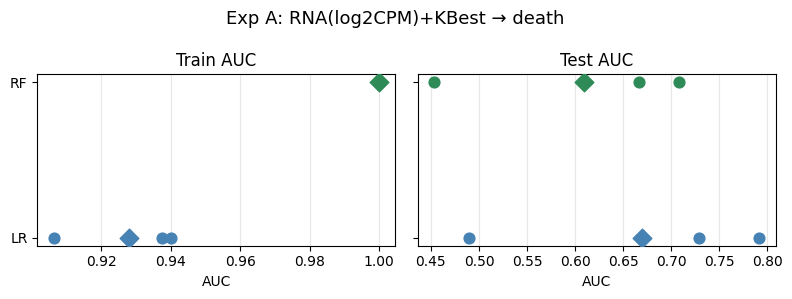

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA(log2CPM)+KBest → death,LR,0.670,0.130,0.633,0.170
1,RNA(log2CPM)+KBest → death,RF,0.609,0.112,0.633,0.131


In [6]:
models_a = {
    "LR": LogisticRegression(solver="saga", l1_ratio=1.0, C=LR_C, max_iter=MAX_ITER, random_state=RANDOM_STATE),
    "RF": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

cv_a1, fold_a1 = run_experiment(
    X_death, y_death, rna_x_columns,
    label="RNA(log2CPM)+KBest → death", models=models_a, select_k=SELECT_K,
)
plot_cv_results(fold_a1, title="Exp A: RNA(log2CPM)+KBest → death")
cv_a1

[RNA(log2CPM)+KBest → OS_central_event]  n=56  positives=21  features=21241


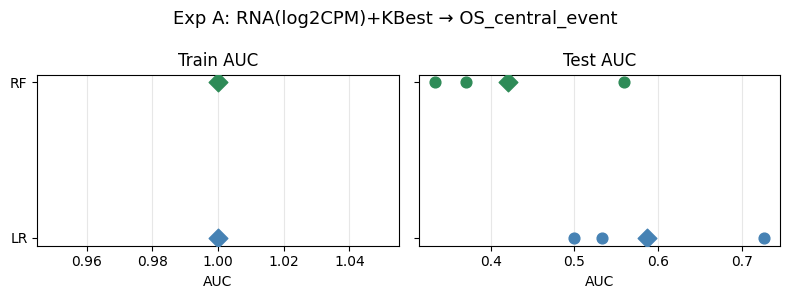

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA(log2CPM)+KBest → OS_central_event,LR,0.586,0.100,0.481,0.111
1,RNA(log2CPM)+KBest → OS_central_event,RF,0.421,0.099,0.497,0.173


In [7]:
cv_a2, fold_a2 = run_experiment(
    X_os, y_os, rna_x_columns,
    label="RNA(log2CPM)+KBest → OS_central_event", models=models_a, select_k=SELECT_K,
)
plot_cv_results(fold_a2, title="Exp A: RNA(log2CPM)+KBest → OS_central_event")
cv_a2

## Experiment B: SelectKBest + LR with small C (no PCA)

Strong L1 penalty drives most coefficients to zero, acting as built-in feature selection. No PCA needed.

[RNA(log2CPM)+KBest+L1(C=small) → death]  n=60  positives=24  features=21241


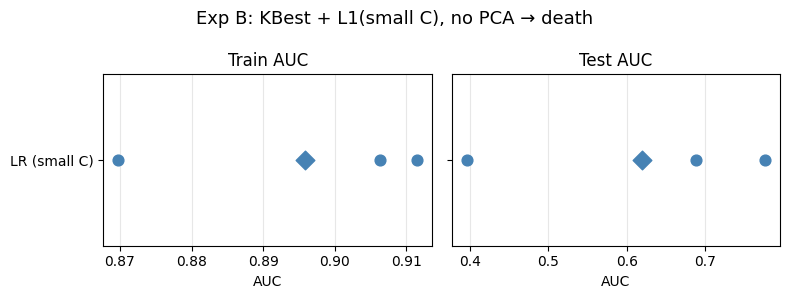

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA(log2CPM)+KBest+L1(C=small) → death,LR (small C),0.62,0.162,0.633,0.024


In [8]:
models_b = {
    "LR (small C)": LogisticRegression(
        solver="saga", l1_ratio=1.0, C=LR_C_SMALL, max_iter=MAX_ITER, random_state=RANDOM_STATE
    ),
}

cv_b1, fold_b1 = run_experiment(
    X_death, y_death, rna_x_columns,
    label="RNA(log2CPM)+KBest+L1(C=small) → death",
    models=models_b, select_k=SELECT_K, use_pca=False,
)
plot_cv_results(fold_b1, title="Exp B: KBest + L1(small C), no PCA → death")
cv_b1

[RNA(log2CPM)+KBest+L1(C=small) → OS_central_event]  n=56  positives=21  features=21241


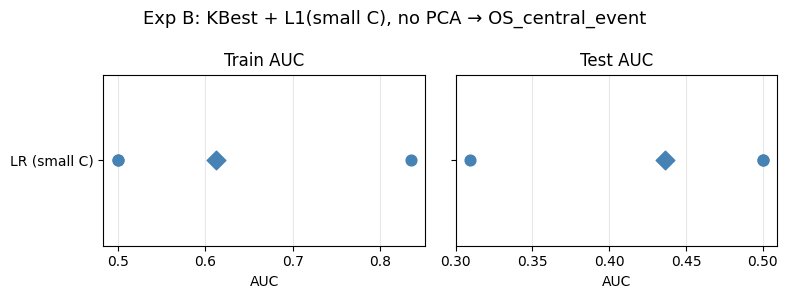

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA(log2CPM)+KBest+L1(C=small) → OS_central_event,LR (small C),0.437,0.09,0.625,0.01


In [9]:
cv_b2, fold_b2 = run_experiment(
    X_os, y_os, rna_x_columns,
    label="RNA(log2CPM)+KBest+L1(C=small) → OS_central_event",
    models=models_b, select_k=SELECT_K, use_pca=False,
)
plot_cv_results(fold_b2, title="Exp B: KBest + L1(small C), no PCA → OS_central_event")
cv_b2

## Summary

Config: SELECT_K=500, MAX_ITER=5000, LR_C=1.0, LR_C_SMALL=0.1

                                       experiment        model  AUC mean  AUC std  Accuracy mean  Accuracy std
                           RNA → death (original)           LR     0.649    0.094          0.617         0.062
                           RNA → death (original)           RF     0.611    0.197          0.600         0.082
                RNA → OS_central_event (original)           LR     0.504    0.171          0.551         0.114
                RNA → OS_central_event (original)           RF     0.474    0.060          0.552         0.079
                       RNA(log2CPM)+KBest → death           LR     0.670    0.130          0.633         0.170
                       RNA(log2CPM)+KBest → death           RF     0.609    0.112          0.633         0.131
            RNA(log2CPM)+KBest → OS_central_event           LR     0.586    0.100          0.481         0.111
            RNA(log2CPM)+KBest → OS_central_event

/Users/amo/programData/hcc-multimodal/hcc_multimodal/baselines/evaluation.py:220: RuntimeWarning: Mean of empty slice
  aucs.mean(),
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/amo/programData/hcc-multimodal/hcc_multimodal/baselines/evaluation.py:220: RuntimeWarning: Mean of empty slice
  aucs.mean(),
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/amo/programData/hcc-multimodal/hcc_multimodal/baselines/evaluation.py:220: RuntimeWarning: Mean of empty slice
  aucs.mean(),
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/

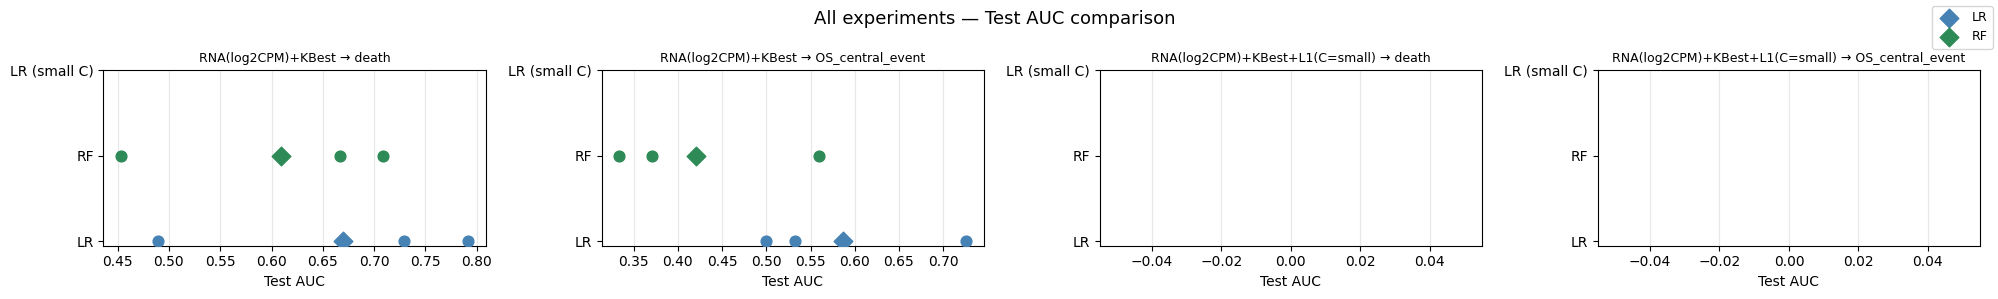

In [10]:
# Original baseline (raw counts, no filtering, no normalisation)
original = pd.DataFrame([
    {"experiment": "RNA → death (original)", "model": "LR", "AUC mean": 0.649, "AUC std": 0.094, "Accuracy mean": 0.617, "Accuracy std": 0.062},
    {"experiment": "RNA → death (original)", "model": "RF", "AUC mean": 0.611, "AUC std": 0.197, "Accuracy mean": 0.600, "Accuracy std": 0.082},
    {"experiment": "RNA → OS_central_event (original)", "model": "LR", "AUC mean": 0.504, "AUC std": 0.171, "Accuracy mean": 0.551, "Accuracy std": 0.114},
    {"experiment": "RNA → OS_central_event (original)", "model": "RF", "AUC mean": 0.474, "AUC std": 0.060, "Accuracy mean": 0.552, "Accuracy std": 0.079},
])

all_cv = pd.concat([original, cv_a1, cv_a2, cv_b1, cv_b2], ignore_index=True)
all_folds = pd.concat([fold_a1, fold_a2, fold_b1, fold_b2], ignore_index=True)

print(f"Config: SELECT_K={SELECT_K}, MAX_ITER={MAX_ITER}, LR_C={LR_C}, LR_C_SMALL={LR_C_SMALL}")
print()
print(all_cv.to_string(index=False))
plot_experiment_comparison(all_folds, title="All experiments — Test AUC comparison")